In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

In [ ]:
wine = pd.read_csv('wine_quality_merged.csv') #checking dataset
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [ ]:
wine.info() #checking values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
print(wine.isnull().sum()) #checking null values

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


In [ ]:
duplicates_all_col = wine.duplicated().sum() #checking duplicates
print(duplicates_all_col)

1177


In [ ]:
wine_cleaned = wine.drop_duplicates() #dropping duplicates
print(wine_cleaned)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
5               7.4              0.66         0.00             1.8      0.075   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30             1.1      0.022   
6496            6.0              0.21         0.38             0.8      0.020   

      free sulfur dioxide  

In [ ]:
wine_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5320 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5320 non-null   float64
 1   volatile acidity      5320 non-null   float64
 2   citric acid           5320 non-null   float64
 3   residual sugar        5320 non-null   float64
 4   chlorides             5320 non-null   float64
 5   free sulfur dioxide   5320 non-null   float64
 6   total sulfur dioxide  5320 non-null   float64
 7   density               5320 non-null   float64
 8   pH                    5320 non-null   float64
 9   sulphates             5320 non-null   float64
 10  alcohol               5320 non-null   float64
 11  quality               5320 non-null   int64  
 12  type                  5320 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 581.9+ KB


In [ ]:
categorical_cols = wine_cleaned.select_dtypes(include=['object', 'category']).columns #checks categorical columns
print(categorical_cols)

Index(['type'], dtype='object')


In [ ]:
wine_cleaned["type"].unique()

array(['red', 'white'], dtype=object)

In [ ]:
wine_cleaned = pd.get_dummies(wine_cleaned, columns=["type"], drop_first=True) #to label categorial data as bool values

In [ ]:
wine_cleaned

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,False
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,True
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,True
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,True
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,True


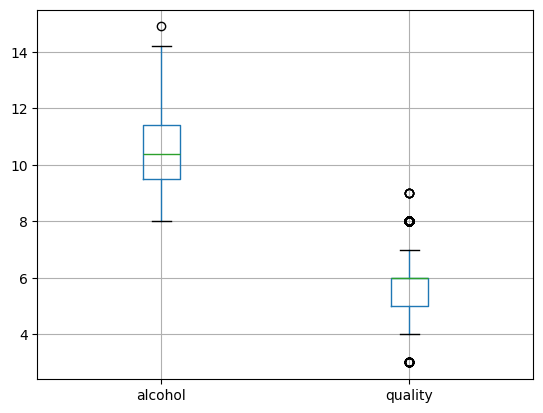

In [ ]:
wine_cleaned[['alcohol', 'quality']].boxplot() #checking outliers between alcohol content and quality values
plt.show()

In [ ]:
Q1 = wine_cleaned['quality'].quantile(0.25)
Q3 = wine_cleaned['quality'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
wine_cleaned['quality'] = wine_cleaned['quality'].clip(lower=lower_bound, upper=upper_bound) #cleaning outliers

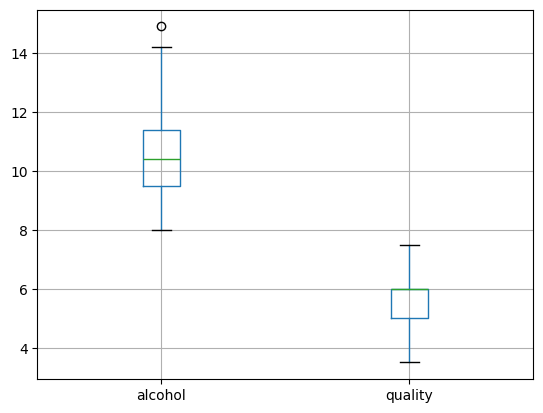

In [ ]:
wine_cleaned[['alcohol', 'quality']].boxplot() #checking outliers between numerical values
plt.show()

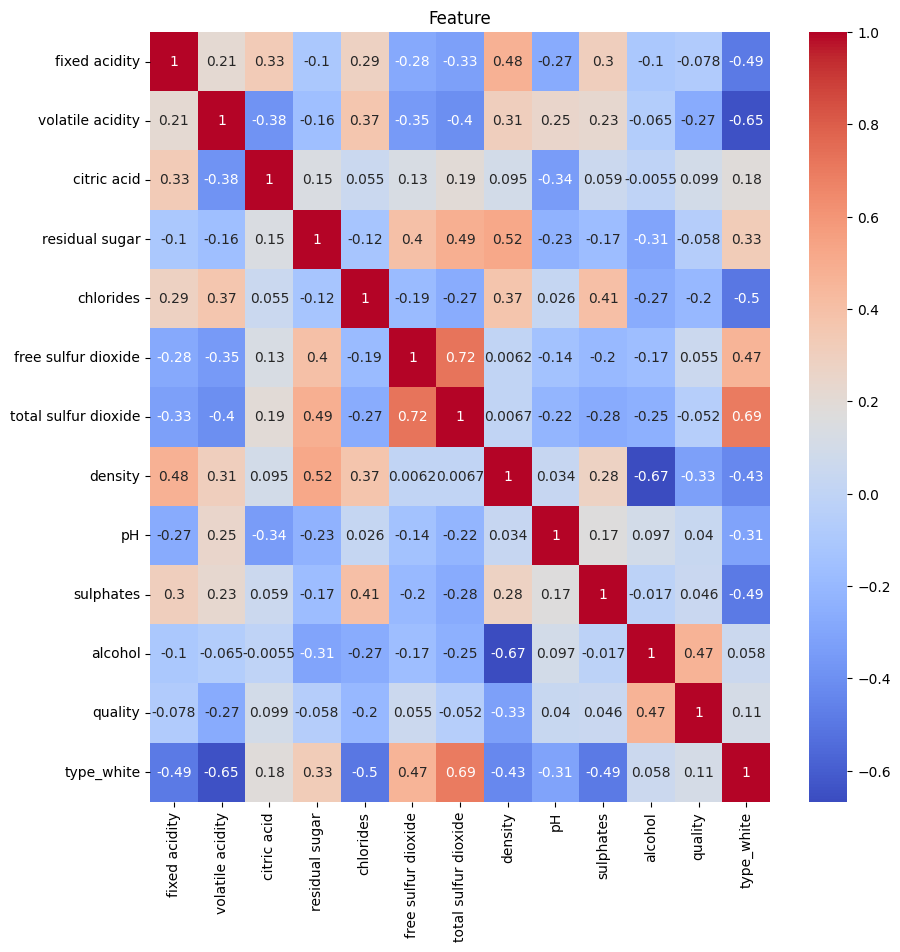

In [ ]:
corr_matrix = wine_cleaned.corr() #checking the correlation
plt.figure(figsize = (10, 10))
sns.heatmap(corr_matrix, annot = True, cmap='coolwarm')
plt.title("Feature")
plt.show()

In [ ]:
wine_cleaned['bound sulfur dioxide'] = wine_cleaned['total sulfur dioxide'] - wine_cleaned['free sulfur dioxide'] + 1

In [ ]:
wine_cleaned['alcohol_content'] = pd.cut(wine_cleaned['alcohol'], #dividing alcohol content if it is low, moderate or high
                              bins=[0, 6, 11, 13],
                              labels=['low', 'moderate', 'high'])

In [ ]:
wine_cleaned = pd.get_dummies(wine_cleaned, columns=['alcohol_content'], drop_first = True)

In [ ]:
wine_cleaned['wine_quality'] = pd.cut(wine_cleaned['quality'], #dividing wine quality if it is low, moderate or high
                              bins=[0, 4, 5, 8],
                              labels=['low_quality', 'moderate_quality', 'high_quality'])

In [ ]:
wine_cleaned = pd.get_dummies(wine_cleaned, columns=['wine_quality'], drop_first = True)

In [ ]:
wine_cleaned

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white,bound sulfur dioxide,alcohol_content_moderate,alcohol_content_high,wine_quality_moderate_quality,wine_quality_high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5.0,False,24.0,True,False,True,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5.0,False,43.0,True,False,True,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5.0,False,40.0,True,False,True,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6.0,False,44.0,True,False,False,True
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5.0,False,28.0,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6.0,True,69.0,False,True,False,True
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5.0,True,112.0,True,False,True,False
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6.0,True,82.0,True,False,False,True
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7.0,True,91.0,False,True,False,True


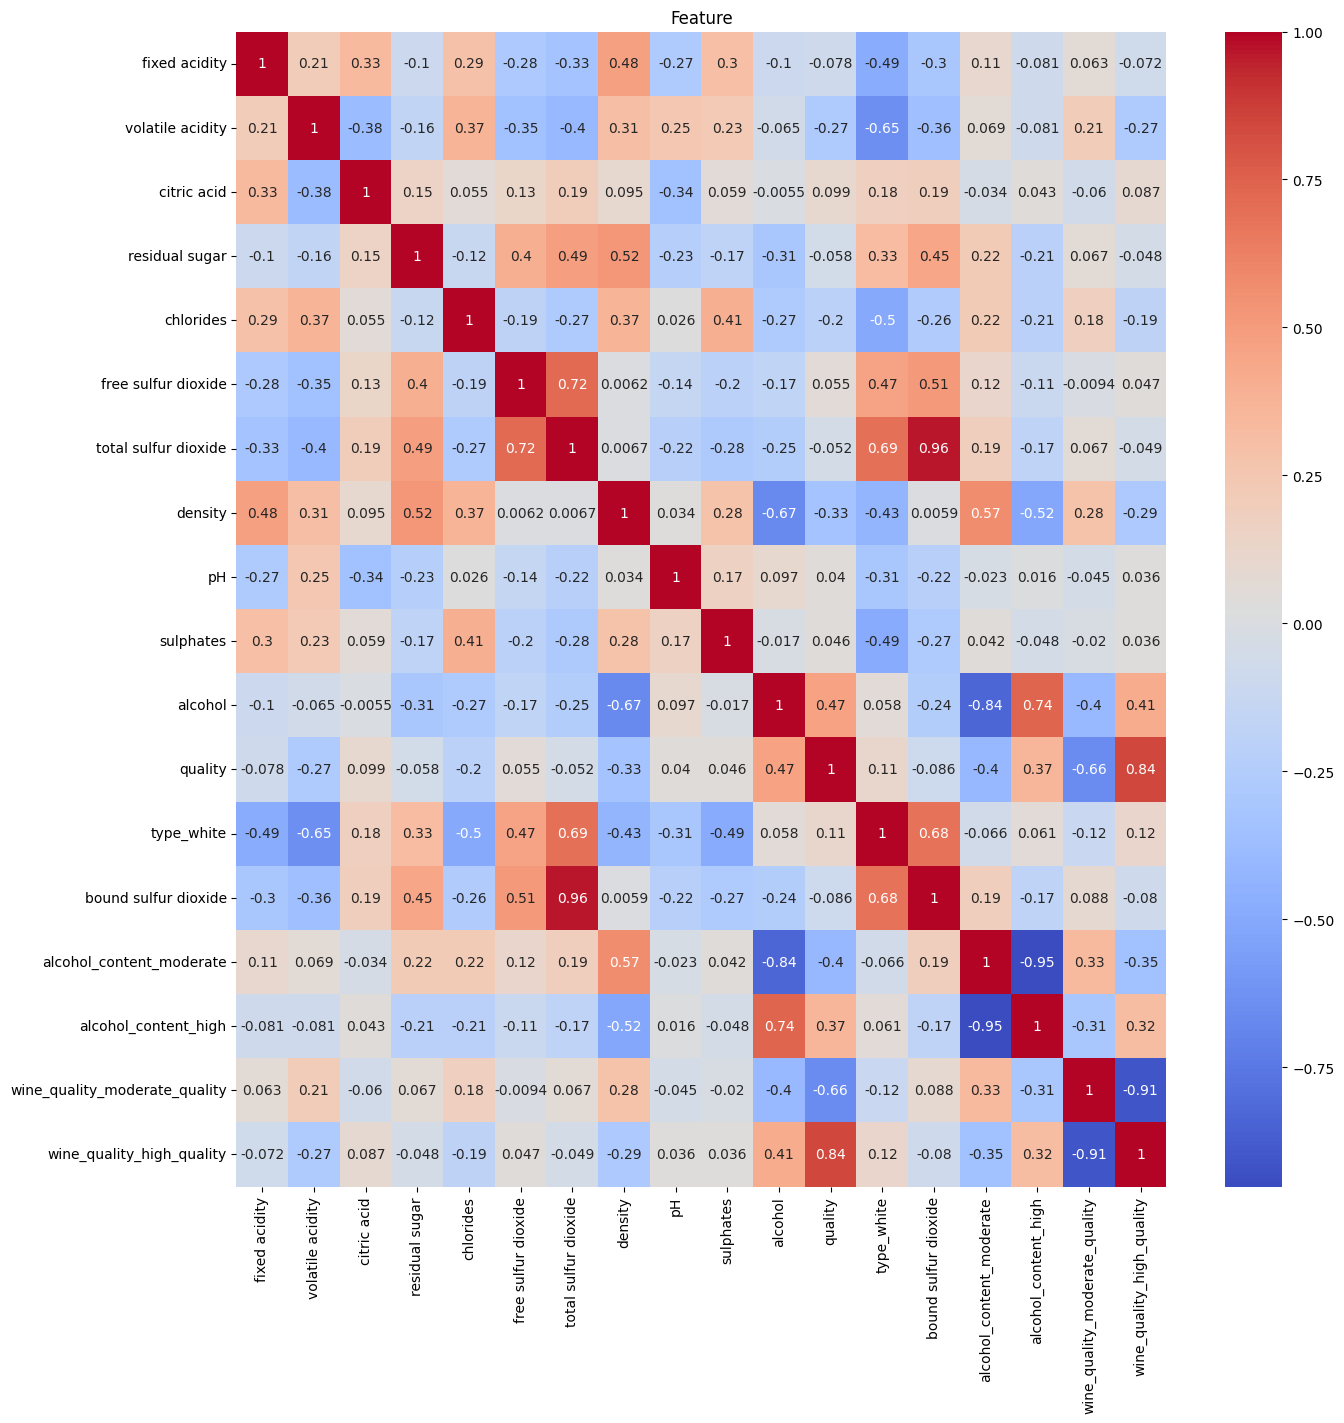

In [ ]:
corr_matrix = wine_cleaned.corr() #checking the correlation
plt.figure(figsize = (15, 15))
sns.heatmap(corr_matrix, annot = True, cmap='coolwarm')
plt.title("Feature")
plt.show()